### SCENARIO D
___

Cluster labels: 
* 0 – Core Frontline Operations Staff (E&I)
* 1 – Specialized Technical Field Experts (E&I)
* 2 – Advanced Governance & Support Specialists
* 3 – Essential Infrastructure Field Crew (E&I)
* 4 – Strategic Business & Real Estate Leaders
* 5 – Governance & Support 

Overview of scenario types:
* Scenario A – Intended Baseline
* Scenario B – Periodic Quota Continuation
* Scenario C – Extended Retirement Age
* Scenario D – Extended Retirement + Periodic Quota
* Scenario E – Accelerated Outsourcing
* Scenario F – Complete No Quota

Overview of the selected KPI charts:
* E&I Scores (Tier 1 clusters)
* SS&G Scores (All clusters)
* Workforce headcount
* Crisis State
* Tier 2 and Tier 3 Monitoring
* Future Readiness Index
* Annual Hires vs Retirees
* Cluster headcount – Core policy narrative
* Senior-to-Junior ratio Tier 1 – Core mechanism
* Support cluster depletion – Contextual policy contrast

In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches

___
SCENARIO D

In [18]:
#LOAD THE COMBINED DATASET
path = 'SCENARIOAF.csv'
master = pd.read_csv(path)

In [19]:
#LOAD SCENARIO D
df = master[master['scenarioID'] == 3].copy()
print(df.info())
print(df.isnull().sum())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 102 to 135
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   scenarioID          34 non-null     int64  
 1   year                34 non-null     int64  
 2   avgBM_0             34 non-null     float64
 3   avgBM_1             34 non-null     float64
 4   avgBM_2             34 non-null     float64
 5   avgBM_3             34 non-null     float64
 6   avgBM_4             34 non-null     float64
 7   avgBM_5             34 non-null     float64
 8   avgTD_0             34 non-null     float64
 9   avgTD_1             34 non-null     float64
 10  avgTD_2             34 non-null     float64
 11  avgTD_3             34 non-null     float64
 12  avgTD_4             34 non-null     float64
 13  avgTD_5             34 non-null     float64
 14  avgEI_0             34 non-null     float64
 15  avgEI_1             34 non-null     float64
 16  avgEI_2           

,scenarioID,year,avgBM_0,avgBM_1,avgBM_2,avgBM_3,avgBM_4,avgBM_5,avgTD_0,avgTD_1,...,count_3,count_4,count_5,gMentor0,gMentor1,gMentor3,annualRetireeCount,annualHireCount,crisisState,scenarioLabel
102,3,2027,3.040534,4.019739,3.768424,3.867134,3.604162,3.420536,3.048175,4.134667,...,3856,65,428,0.0,1.0,1.000000,0,0,0,D - Extended Retirement + Periodic Quota
103,3,2028,2.712259,3.972156,3.332144,3.770700,3.084765,3.001229,2.732893,4.179610,...,4501,65,428,0.0,1.0,0.820793,0,0,0,D - Extended Retirement + Periodic Quota
104,3,2029,2.744944,3.948432,3.345833,3.755048,3.096126,3.010105,2.763738,4.178500,...,4743,65,428,0.0,1.0,0.747605,0,0,0,D - Extended Retirement + Periodic Quota
105,3,2030,2.769836,3.942824,3.340748,3.753073,3.106984,3.018641,2.787076,4.189758,...,4917,65,428,0.0,1.0,1.000000,0,0,0,D - Extended Retirement + Periodic Quota
106,3,2031,2.796148,3.929465,3.353076,3.914245,3.117405,3.028255,2.811784,4.193972,...,5122,65,427,0.0,1.0,1.000000,9,0,0,D - Extended Retirement + Periodic Quota


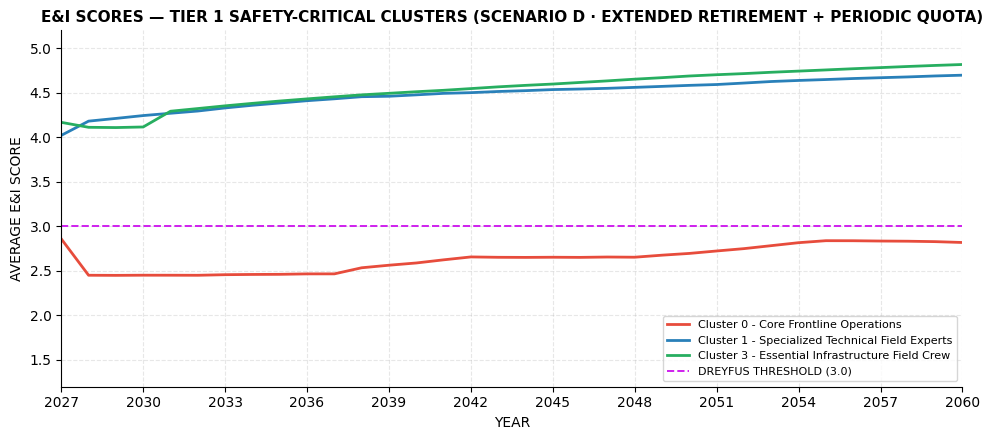

In [20]:
# PLOT 1 — E&I SCORES · TIER 1 CLUSTERS · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
DREYFUS = 3.0
COLOURS = {
    'avgEI_0': '#E74C3C',  # Cluster 0 – Core Frontline Operations Staff
    'avgEI_1': '#2980B9',  # Cluster 1 – Specialized Technical Field Experts
    'avgEI_3': '#27AE60',  # Cluster 3 – Essential Infrastructure Field Crew
}
LABELS = {
    'avgEI_0': 'Cluster 0 - Core Frontline Operations',
    'avgEI_1': 'Cluster 1 - Specialized Technical Field Experts',
    'avgEI_3': 'Cluster 3 - Essential Infrastructure Field Crew',
}

fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, label=LABELS[col])
ax.axhline(DREYFUS, color="#CF20EE", linewidth=1.4, linestyle='--', label='DREYFUS THRESHOLD (3.0)')
ax.set_title('E&I SCORES — TIER 1 SAFETY-CRITICAL CLUSTERS (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('AVERAGE E&I SCORE')
ax.set_xlim(2027, 2060)
ax.set_ylim(1.2, 5.2)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

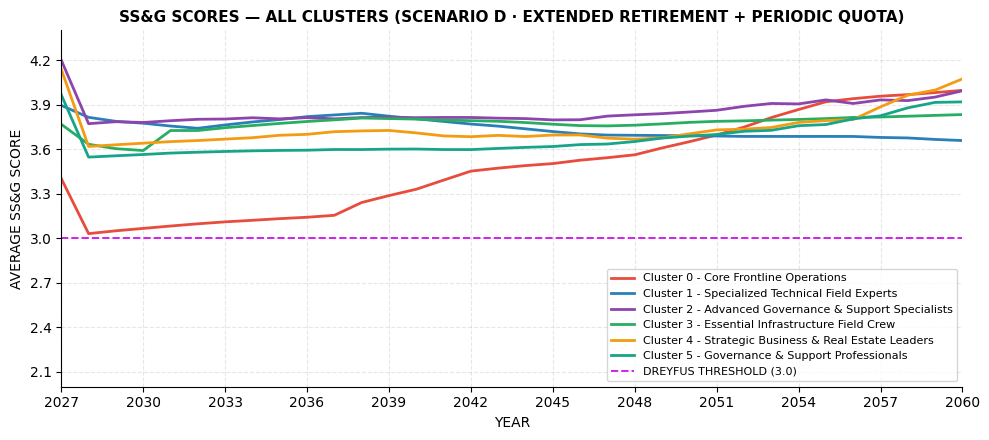

In [21]:
# PLOT 2 — SS&G SCORES · ALL CLUSTERS · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
DREYFUS = 3.0
COLOURS = {
    'avgSSG_0': '#E74C3C',  # Cluster 0 – Core Frontline Operations Staff
    'avgSSG_1': '#2980B9',  # Cluster 1 – Specialized Technical Field Experts
    'avgSSG_2': '#8E44AD',  # Cluster 2 – Advanced Governance & Support Specialists
    'avgSSG_3': '#27AE60',  # Cluster 3 – Essential Infrastructure Field Crew
    'avgSSG_4': '#F39C12',  # Cluster 4 – Strategic Business & Real Estate Leaders
    'avgSSG_5': '#17A589',  # Cluster 5 – Governance & Support Professionals
}
LABELS = {
    'avgSSG_0': 'Cluster 0 - Core Frontline Operations',
    'avgSSG_1': 'Cluster 1 - Specialized Technical Field Experts',
    'avgSSG_2': 'Cluster 2 - Advanced Governance & Support Specialists',
    'avgSSG_3': 'Cluster 3 - Essential Infrastructure Field Crew',
    'avgSSG_4': 'Cluster 4 - Strategic Business & Real Estate Leaders',
    'avgSSG_5': 'Cluster 5 - Governance & Support Professionals',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, label=LABELS[col])
ax.axhline(DREYFUS, color='#CF20EE', linewidth=1.4, linestyle='--', label='DREYFUS THRESHOLD (3.0)')
ax.set_title('SS&G SCORES — ALL CLUSTERS (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('AVERAGE SS&G SCORE')
ax.set_xlim(2027, 2060)
ax.set_ylim(2.0, 4.4)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right', )
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

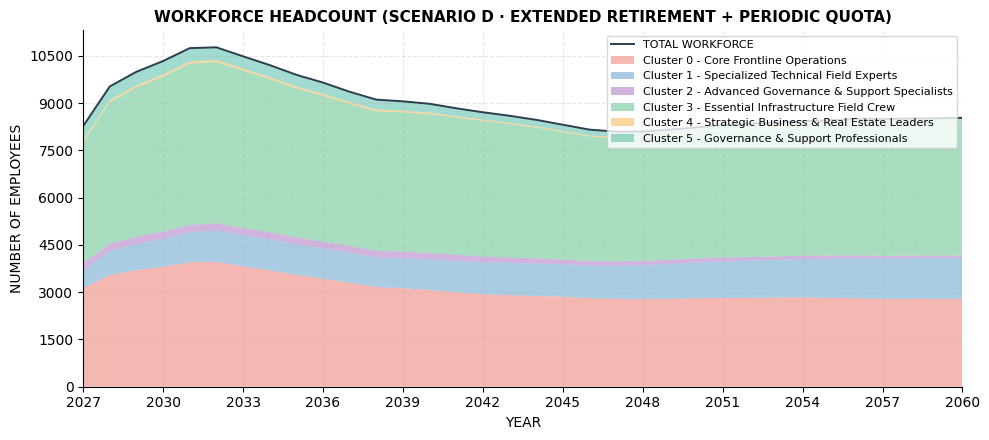

In [22]:
# PLOT 3 — WORKFORCE HEADCOUNT · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(df['year'], df['count_0'] + df['count_1'] + df['count_2'] + df['count_3'] + df['count_4'] + df['count_5'], color='#2C3E50', linewidth=1.4, label='TOTAL WORKFORCE')
ax.stackplot(df['year'],
             df['count_0'], df['count_1'], df['count_2'],
             df['count_3'], df['count_4'], df['count_5'],
             labels=[
                 'Cluster 0 - Core Frontline Operations',
                 'Cluster 1 - Specialized Technical Field Experts',
                 'Cluster 2 - Advanced Governance & Support Specialists',
                 'Cluster 3 - Essential Infrastructure Field Crew',
                 'Cluster 4 - Strategic Business & Real Estate Leaders',
                 'Cluster 5 - Governance & Support Professionals',
             ],
             colors=['#E74C3C','#2980B9','#8E44AD','#27AE60','#F39C12','#17A589'],
             alpha=0.4)
ax.set_title('WORKFORCE HEADCOUNT (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2027, 2060)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

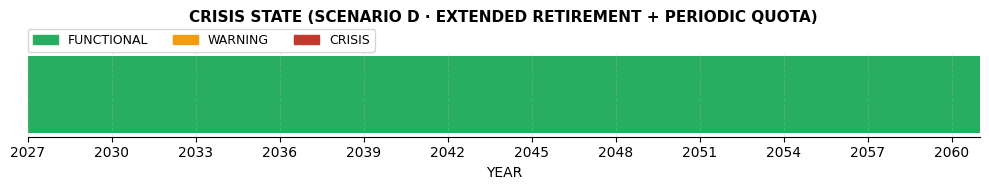

In [23]:
# PLOT 4 — CRISIS STATE · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
STATECOLOURS = {0: '#27AE60', 1: '#F39C12', 2: '#C0392B'}
STATELABELS  = {0: 'FUNCTIONAL', 1: 'WARNING', 2: 'CRISIS'}
fig, ax = plt.subplots(figsize=(10, 2))
for _, row in df.iterrows():
    ax.barh(y=0, width=1, left=row['year'], color=STATECOLOURS[row['crisisState']], edgecolor='none')
patches = [mpatches.Patch(color=STATECOLOURS[s], label=STATELABELS[s]) for s in [0, 1, 2]]
ax.legend(handles=patches, fontsize=9, loc='lower left', bbox_to_anchor=(0.0, 1.01), ncol=3, borderaxespad=0)
ax.set_title('CRISIS STATE (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold', pad=22)
ax.set_xlabel('YEAR')
ax.set_xlim(2027, 2061)
ax.set_xticks(range(2027, 2061, 3))
ax.set_yticks([])
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
sns.despine(left=True)
plt.tight_layout()
plt.show();

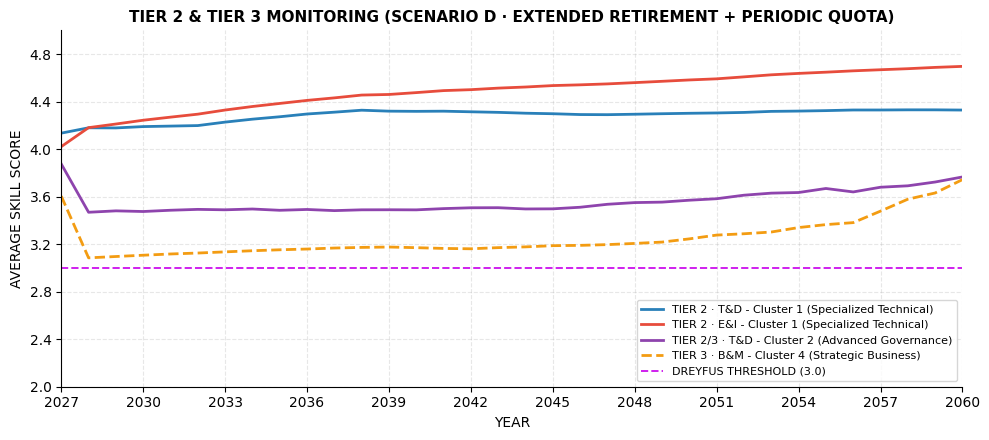

In [25]:
# PLOT 5 — TIER 2 & TIER 3 MONITORING · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
DREYFUS = 3.0
TIER2 = {
    'avgTD_1': ('#2980B9', 'TIER 2 · T&D - Cluster 1 (Specialized Technical)'),
    'avgEI_1': ('#E74C3C', 'TIER 2 · E&I - Cluster 1 (Specialized Technical)'),
    'avgTD_2': ('#8E44AD', 'TIER 2/3 · T&D - Cluster 2 (Advanced Governance)'),
}
TIER3 = {'avgBM_4': ('#F39C12', 'TIER 3 · B&M - Cluster 4 (Strategic Business)')}

fig, ax = plt.subplots(figsize=(10, 4.5))
for col, (colour, label) in TIER2.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, linestyle='-', label=label)

for col, (colour, label) in TIER3.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, linestyle='--', label=label)

ax.axhline(DREYFUS, color='#CF20EE', linewidth=1.4, linestyle='--', label='DREYFUS THRESHOLD (3.0)')
ax.set_title('TIER 2 & TIER 3 MONITORING (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('AVERAGE SKILL SCORE')
ax.set_xlim(2027, 2060)
ax.set_ylim(2.0, 5.0)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

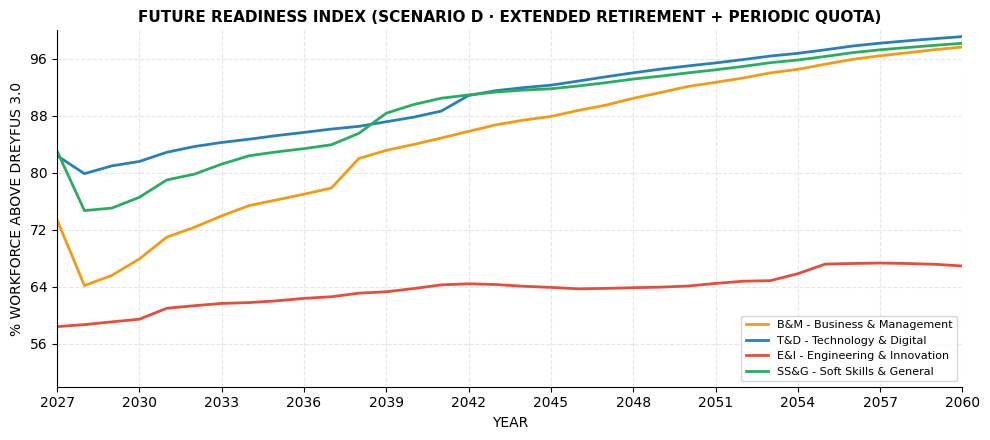

In [26]:
# PLOT 6 — FUTURE READINESS INDEX · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
COLOURS = {
    'friBM':  '#F39C12',  # Business & Management
    'friTD':  '#2980B9',  # Technology & Digital
    'friEI':  '#E74C3C',  # Engineering & Innovation
    'friSSG': '#27AE60',  # Soft Skills & General
}
LABELS = {
    'friBM':  'B&M - Business & Management',
    'friTD':  'T&D - Technology & Digital',
    'friEI':  'E&I - Engineering & Innovation',
    'friSSG': 'SS&G - Soft Skills & General',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col] * 100, color=colour, linewidth=2, label=LABELS[col])
ax.set_title('FUTURE READINESS INDEX (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('% WORKFORCE ABOVE DREYFUS 3.0')
ax.set_xlim(2027, 2060)
ax.set_ylim(50, 100)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

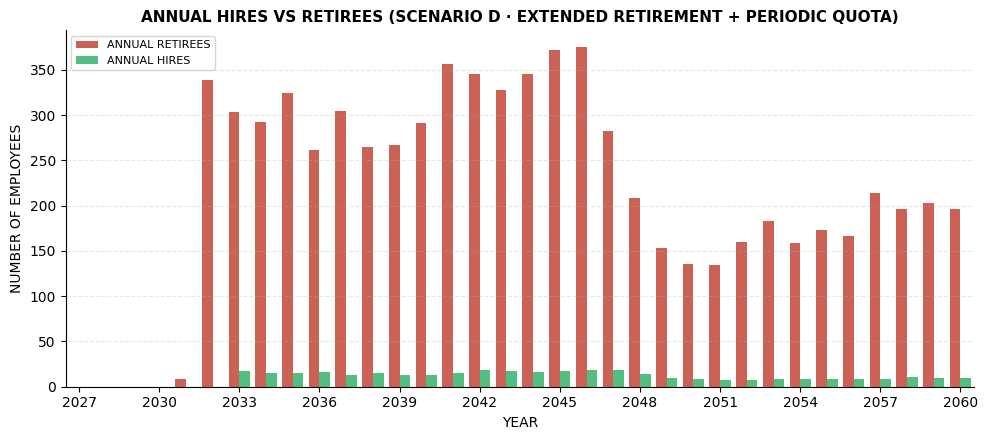

In [27]:
# PLOT 7 — ANNUAL HIRES VS RETIREES · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(df['year'] - 0.2, df['annualRetireeCount'], width=0.4, color='#C0392B', alpha=0.8, label='ANNUAL RETIREES')
ax.bar(df['year'] + 0.2, df['annualHireCount'], width=0.4, color='#27AE60', alpha=0.8, label='ANNUAL HIRES')
ax.set_title('ANNUAL HIRES VS RETIREES (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2026.5, 2060.5)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

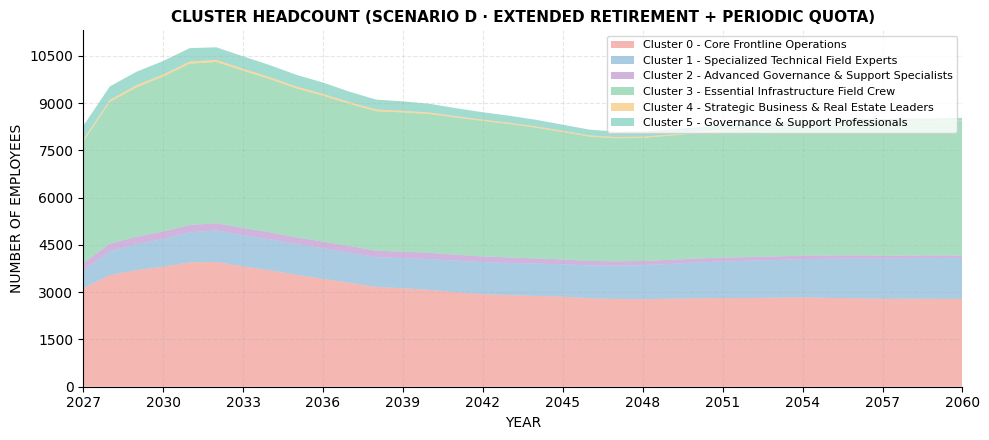

In [28]:
# PLOT 10 — CLUSTER HEADCOUNT · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
COLOURS = {
    'count_0': '#E74C3C',  # Cluster 0 – Core Frontline Operations Staff
    'count_1': '#2980B9',  # Cluster 1 – Specialized Technical Field Experts
    'count_2': '#8E44AD',  # Cluster 2 – Advanced Governance & Support Specialists
    'count_3': '#27AE60',  # Cluster 3 – Essential Infrastructure Field Crew
    'count_4': '#F39C12',  # Cluster 4 – Strategic Business & Real Estate Leaders
    'count_5': '#17A589',  # Cluster 5 – Governance & Support Professionals
}
LABELS = {
    'count_0': 'Cluster 0 - Core Frontline Operations',
    'count_1': 'Cluster 1 - Specialized Technical Field Experts',
    'count_2': 'Cluster 2 - Advanced Governance & Support Specialists',
    'count_3': 'Cluster 3 - Essential Infrastructure Field Crew',
    'count_4': 'Cluster 4 - Strategic Business & Real Estate Leaders',
    'count_5': 'Cluster 5 - Governance & Support Professionals',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.stackplot(df['year'],
             df['count_0'], df['count_1'], df['count_2'],
             df['count_3'], df['count_4'], df['count_5'],
             labels=list(LABELS.values()),
             colors=list(COLOURS.values()),
             alpha=0.4)
ax.set_title('CLUSTER HEADCOUNT (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2027, 2060)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

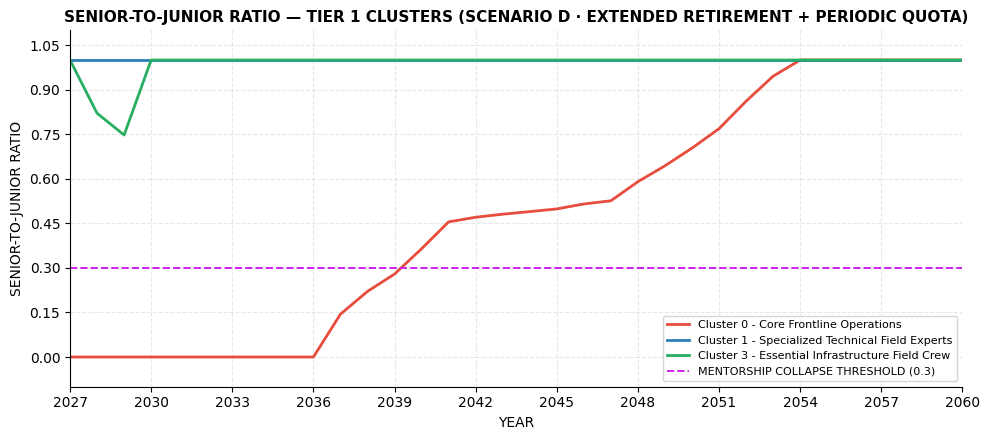

In [29]:
# PLOT 11 — SENIOR-TO-JUNIOR RATIO · TIER 1 CLUSTERS · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
COLOURS = {
    'gMentor0': '#E74C3C',  # Cluster 0 – Core Frontline Operations Staff
    'gMentor1': '#2980B9',  # Cluster 1 – Specialized Technical Field Experts
    'gMentor3': '#27AE60',  # Cluster 3 – Essential Infrastructure Field Crew
}
LABELS = {
    'gMentor0': 'Cluster 0 - Core Frontline Operations',
    'gMentor1': 'Cluster 1 - Specialized Technical Field Experts',
    'gMentor3': 'Cluster 3 - Essential Infrastructure Field Crew',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, label=LABELS[col])
ax.axhline(0.3, color='#CF20EE', linewidth=1.4, linestyle='--', label='MENTORSHIP COLLAPSE THRESHOLD (0.3)')
ax.set_title('SENIOR-TO-JUNIOR RATIO — TIER 1 CLUSTERS (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('SENIOR-TO-JUNIOR RATIO')
ax.set_xlim(2027, 2060)
ax.set_ylim(-0.1, 1.1)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

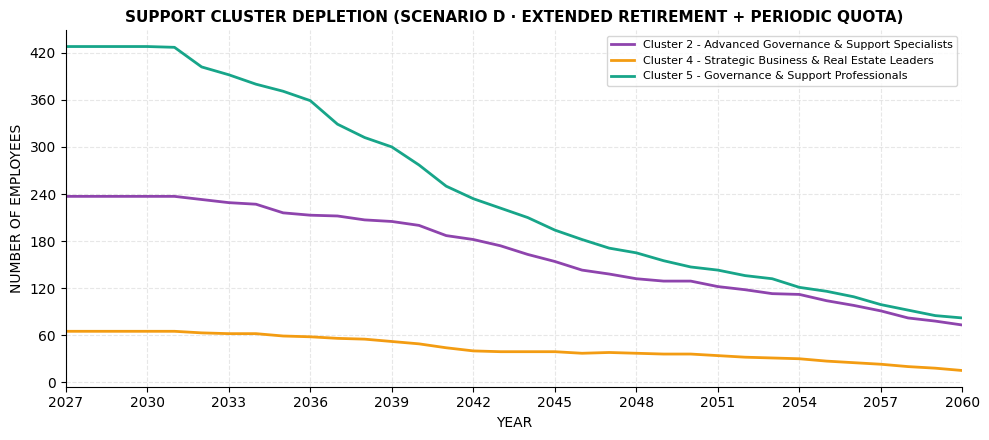

In [30]:
# PLOT 12 — SUPPORT CLUSTER DEPLETION · SCENARIO D
df = master[master['scenarioID'] == 3].copy()
COLOURS = {
    'count_2': '#8E44AD',  # Cluster 2 – Advanced Governance & Support Specialists
    'count_4': '#F39C12',  # Cluster 4 – Strategic Business & Real Estate Leaders
    'count_5': '#17A589',  # Cluster 5 – Governance & Support Professionals
}
LABELS = {
    'count_2': 'Cluster 2 - Advanced Governance & Support Specialists',
    'count_4': 'Cluster 4 - Strategic Business & Real Estate Leaders',
    'count_5': 'Cluster 5 - Governance & Support Professionals',
}
fig, ax = plt.subplots(figsize=(10, 4.5))
for col, colour in COLOURS.items():
    ax.plot(df['year'], df[col], color=colour, linewidth=2, label=LABELS[col])
ax.set_title('SUPPORT CLUSTER DEPLETION (SCENARIO D · EXTENDED RETIREMENT + PERIODIC QUOTA)', fontsize=11, fontweight='bold')
ax.set_xlabel('YEAR')
ax.set_ylabel('NUMBER OF EMPLOYEES')
ax.set_xlim(2027, 2060)
ax.set_xticks(range(2027, 2061, 3))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show();

___
**END**